In [38]:
import torch 


T = 1000
c = torch.randn((T,))
for t in range(1, 1000): 
    c[t] = c[t-1] * 0.7 + torch.randn(1,1)

y = torch.randn_like(c)
for t in range(1, 1000): 
    y[t] = 0.5*y[t-1] + 0.5*c[t-1]

t = torch.linspace(1,100,1000)

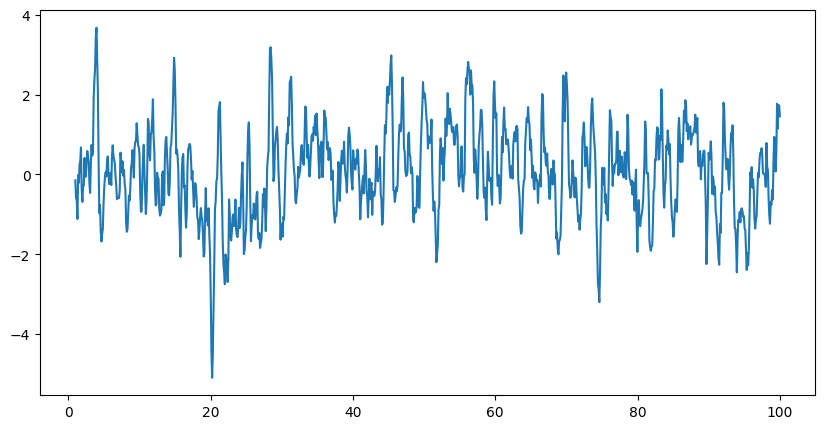

In [40]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10,5))
plt.plot(t.detach().numpy(), y.detach().numpy()) 
plt.show()

In [41]:
from TimeGradUtils.diffModules import BaseScheduler, DDPM_TimeGrad
from TimeGradUtils.denoisingRNN import TimeGradRNN_FH, DenoisingNetTimeGrad, TrainSpec
from TimeGradUtils.trainingTg import training_TimeGrad_FH


spec_tg = TrainSpec(t0 = 100,
                    Lookback = 64,
                    batch_size = 64,
                    epochs = 1000,
                    patience = 100,
                    lr = 1e-3,
                    print_loss = False,
                    min_loss= 0.37
                    )

# Diffusion steps, hidden state, lookback
steps = 100
h = 8

linear_scheduler = BaseScheduler(num_train_timesteps = steps, mode = "linear", beta_K=0.1)
timegrad = DDPM_TimeGrad(scheduler=linear_scheduler)


hidden_dim_timegrad = [8,]
time_TimeGrad = []


eModel = DenoisingNetTimeGrad(in_dim = 2, hidden_size = h, dim_hids = [8, 16, 8], num_timesteps = steps)
hModel = TimeGradRNN_FH(input_size=1, hidden_size=h, cell='LSTM')

losses, best_loss, time_to_train = training_TimeGrad_FH(
    y=y, 
    c = c,
    DeNetmodel = eModel, 
    RNNModel = hModel, 
    diffusion = timegrad, 
    ts = spec_tg
    )

ModuleNotFoundError: No module named 'tqdm'